# 01 · Análise exploratória — Marketing bancário português

**Pergunta de negócio.** Um banco português ligou para clientes oferecendo um depósito a prazo. Queremos saber
**para quem ligar primeiro** (e quantas vezes insistir), usando só informação disponível *antes* da ligação.

**Dados.** `bank-full.csv` (UCI Bank Marketing, via Kaggle): 45.211 contatos, 16 variáveis + alvo `y`
(o cliente assinou o depósito?).

**Roteiro deste notebook**
1. Visão geral e tipos
2. Qualidade dos dados e valores ausentes (`unknown`)
3. Por que não usar o `bank_cleaned.csv`
4. O alvo e o paradoxo da acurácia
5. Os dados têm tempo: reconstrução do período
6. Variáveis numéricas e outliers
7. Variáveis categóricas
8. Relação com o alvo: perfil ou época?
9. Quantas vezes ligar: tentativas
10. `duration` e vazamento de informação
11. Quando cada variável é conhecida → conjunto de features
12. Resumo dos achados

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from bank_marketing.config import DATA_RAW, EXCLUDED, FEATURES, PROJECT_ROOT
from bank_marketing.data import add_period, clean, load_raw
from bank_marketing.eda import attempt_hazard, attempt_lift, cap_attempts_impact, lift_by, unknown_summary
from bank_marketing.evaluation import save_metrics
from bank_marketing import plots
from bank_marketing.plots import BLUE, GRAY, INK_2, ORANGE, BASELINE, MUTED

plots.apply_style()
pd.set_option("display.max_columns", 30)
pd.set_option("display.float_format", "{:.3f}".format)

MONTHS_PT = ["jan", "fev", "mar", "abr", "mai", "jun", "jul", "ago", "set", "out", "nov", "dez"]
eda_facts = {}

## 1. Visão geral e tipos

In [2]:
raw = load_raw()
print(f"{raw.shape[0]:,} linhas × {raw.shape[1]} colunas")
raw.head()

45,211 linhas × 17 colunas


,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
0,58,management,married,tertiary,no,2143,yes,no,unknown,5,may,261,1,-1,0,unknown,no
1,44,technician,single,secondary,no,29,yes,no,unknown,5,may,151,1,-1,0,unknown,no
2,33,entrepreneur,married,secondary,no,2,yes,yes,unknown,5,may,76,1,-1,0,unknown,no
3,47,blue-collar,married,unknown,no,1506,yes,no,unknown,5,may,92,1,-1,0,unknown,no
4,33,unknown,single,unknown,no,1,no,no,unknown,5,may,198,1,-1,0,unknown,no


In [3]:
raw.info()

<class 'pandas.DataFrame'>
RangeIndex: 45211 entries, 0 to 45210
Data columns (total 17 columns):
 #   Column     Non-Null Count  Dtype
---  ------     --------------  -----
 0   age        45211 non-null  int64
 1   job        45211 non-null  str  
 2   marital    45211 non-null  str  
 3   education  45211 non-null  str  
 4   default    45211 non-null  str  
 5   balance    45211 non-null  int64
 6   housing    45211 non-null  str  
 7   loan       45211 non-null  str  
 8   contact    45211 non-null  str  
 9   day        45211 non-null  int64
 10  month      45211 non-null  str  
 11  duration   45211 non-null  int64
 12  campaign   45211 non-null  int64
 13  pdays      45211 non-null  int64
 14  previous   45211 non-null  int64
 15  poutcome   45211 non-null  str  
 16  y          45211 non-null  str  
dtypes: int64(7), str(10)
memory usage: 5.9 MB


In [4]:
raw.describe().T

,count,mean,std,min,25%,50%,75%,max
age,45211.000,40.936,10.619,18.000,33.000,39.000,48.000,95.000
balance,45211.000,1362.272,3044.766,-8019.000,72.000,448.000,1428.000,102127.000
day,45211.000,15.806,8.322,1.000,8.000,16.000,21.000,31.000
duration,45211.000,258.163,257.528,0.000,103.000,180.000,319.000,4918.000
campaign,45211.000,2.764,3.098,1.000,1.000,2.000,3.000,63.000
pdays,45211.000,40.198,100.129,-1.000,-1.000,-1.000,-1.000,871.000
previous,45211.000,0.580,2.303,0.000,0.000,0.000,0.000,275.000


In [5]:
categorical_cols = raw.select_dtypes(exclude="number").columns.drop("y")
pd.DataFrame(
    {
        "n_categorias": raw[categorical_cols].nunique(),
        "mais_frequente": raw[categorical_cols].mode().iloc[0],
        "freq_mais_frequente": [raw[c].value_counts(normalize=True).iloc[0] for c in categorical_cols],
    }
)

,n_categorias,mais_frequente,freq_mais_frequente
job,12,blue-collar,0.215
marital,3,married,0.602
education,4,secondary,0.513
default,2,no,0.982
housing,2,yes,0.556
loan,2,no,0.840
contact,3,cellular,0.648
month,12,may,0.304
poutcome,4,unknown,0.817


**Leitura rápida**
- 7 variáveis numéricas e 9 categóricas; nenhuma com tipo inconsistente.
- Caudas longas: `balance` vai de −8.019 a 102.127 €, `campaign` até 63 tentativas, `previous` até 275 e
  `duration` até 4.918 s. A mediana de `pdays` é −1, ou seja, a maioria nunca foi contatada antes.
- `default` é quase constante (98% "no").

## 2. Qualidade dos dados e valores ausentes

Não há `NaN` nem linhas duplicadas. A ausência aparece de outro jeito: como a categoria **`unknown`**, e como
o valor sentinela `pdays = -1` ("nunca contatado").

In [6]:
print("NaN por coluna:", int(raw.isna().sum().sum()), "| linhas duplicadas:", int(raw.duplicated().sum()))
raw_y = raw.assign(y=(raw["y"] == "yes").astype(int))
unknowns = unknown_summary(raw_y, ["job", "education", "contact", "poutcome"])
unknowns

NaN por coluna: 0 | linhas duplicadas: 0


,n_unknown,pct_unknown,rate_unknown,rate_known
job,288,0.006,0.118,0.117
education,1857,0.041,0.136,0.116
contact,13020,0.288,0.041,0.148
poutcome,36959,0.817,0.092,0.231


In [7]:
never = raw["pdays"] == -1
consistency = pd.crosstab(never.rename("pdays == -1"), raw["poutcome"].eq("unknown").rename("poutcome == unknown"))
print("previous == 0 entre os que têm pdays == -1:", (raw.loc[never, "previous"] == 0).mean())
consistency

previous == 0 entre os que têm pdays == -1: 1.0


poutcome == unknown,False,True
pdays == -1,,
False,8252,5
True,0,36954


**Diagnóstico e decisão**

| Coluna | % unknown | Natureza | Decisão |
|---|---|---|---|
| `job` | 0,6% | ausência pontual | manter `unknown` como categoria |
| `education` | 4,1% | ausência pontual | manter `unknown` como categoria |
| `contact` | 28,8% | **artefato de coleta** (quase tudo em mai–jun/2008, ver seção 5) | manter como categoria |
| `poutcome` | 81,7% | **estrutural**: `pdays = -1` ⇔ `previous = 0` ⇔ `unknown` (36.954 linhas) | recodificar para `nonexistent` ("nunca contatado") |

**Por que não imputar?** A ausência não é aleatória: quem tem `contact = unknown` converte 4,1% contra
14,9% no celular. Imputar pela moda apagaria esse sinal e inventaria um canal que não aconteceu. Manter
`unknown` como categoria preserva a informação e é trivial para one-hot e árvores. As 5 linhas com
`pdays ≠ -1` e `poutcome = unknown` são inconsistências pontuais e continuam como `unknown`.

## 3. Por que não usar o `bank_cleaned.csv`

O Kaggle traz um segundo arquivo, já "limpo". Comparamos com o original antes de decidir.

In [8]:
cleaned = pd.read_csv(PROJECT_ROOT / "data" / "raw" / "bank_cleaned.csv", index_col=0)
dropped = raw.loc[~raw.index.isin(cleaned.index)]
print(f"bank_cleaned: {cleaned.shape[0]:,} linhas → {len(dropped):,} linhas a menos que o original")
print("colunas que sumiram:", sorted(set(raw.columns) - set(cleaned.columns) - {"y"}), "(y virou response/response_binary)")
print("poutcome no cleaned:", cleaned["poutcome"].value_counts().to_dict())
print("linhas removidas com education == unknown:", int((dropped["education"] == "unknown").sum()),
      "de", int((raw["education"] == "unknown").sum()))
print("duration no cleaned (primeiras linhas, em minutos):", cleaned["duration"].head(3).tolist())

bank_cleaned: 40,841 linhas → 4,370 linhas a menos que o original
colunas que sumiram: ['contact'] (y virou response/response_binary)
poutcome no cleaned: {'unknown': 34802, 'failure': 4648, 'success': 1391}
linhas removidas com education == unknown: 1857 de 1857
duration no cleaned (primeiras linhas, em minutos): [4.35, 2.52, 1.27]


O arquivo "limpo" remove 4.370 linhas (todas as de `education = unknown` e outras sem critério documentado),
descarta a coluna `contact`, elimina `poutcome = other` e troca a unidade de `duration`. Como a limpeza não é
documentada e joga informação fora, **usamos só o `bank-full.csv` original** e fazemos cada tratamento de
forma explícita e reprodutível.

## 4. O alvo e o paradoxo da acurácia

In [9]:
base_rate = raw_y["y"].mean()
calls = raw["campaign"].sum()
per_call = raw_y["y"].sum() / calls
print(f"conversão por cliente: {base_rate:.1%}  ({raw_y['y'].sum():,} adesões)")
print(f"acurácia de um modelo que sempre responde 'não': {1 - base_rate:.1%}")
print(f"conversão por ligação: {per_call:.1%}  ({raw_y['y'].sum():,} adesões em {calls:,} ligações)")
eda_facts.update(base_rate=base_rate, dummy_accuracy=1 - base_rate, n_rows=len(raw),
                 n_subscriptions=int(raw_y["y"].sum()), n_calls=int(calls), conversion_per_call=per_call)

conversão por cliente: 11.7%  (5,289 adesões)
acurácia de um modelo que sempre responde 'não': 88.3%
conversão por ligação: 4.2%  (5,289 adesões em 124,956 ligações)


O alvo é desbalanceado: **11,7%** dos clientes aderem. Um "modelo" que sempre diz *não* acerta 88,3%, então
**acurácia não serve** para avaliar este problema. Na seção de modelagem usamos métricas de ordenação e de
negócio. Do ponto de vista operacional o número importante é outro: **só 4,2% das ligações** resultam em adesão.

## 5. Os dados têm tempo

O arquivo não tem coluna de ano, mas a documentação da UCI diz que ele está **ordenado por data, de maio/2008
a novembro/2010**. Reconstruímos o ano pela sequência dos meses: sempre que o mês "volta" (ex.: dez → jan), o
ano avança (`data.add_period`, com testes).

In [10]:
df = clean(add_period(raw))
print("primeiro período:", df["period"].iloc[0], "| último:", df["period"].iloc[-1],
      "| meses distintos:", df["period"].nunique())
by_period = df.groupby("period").agg(
    calls=("y", "size"),
    conversion=("y", "mean"),
    contact_unknown=("contact", lambda s: (s == "unknown").mean()),
    contacted_before=("contacted_before", "mean"),
    avg_attempts=("campaign", "mean"),
)
by_year = df.groupby("year").agg(rows=("y", "size"), conversion=("y", "mean"),
                                 avg_attempts=("campaign", "mean"), contacted_before=("contacted_before", "mean"))
by_year

primeiro período: 2008-05 | último: 2010-11 | meses distintos: 30


,rows,conversion,avg_attempts,contacted_before
year,,,,
2008,27729,0.051,3.186,0.033
2009,14862,0.171,2.130,0.378
2010,2620,0.516,1.885,0.657


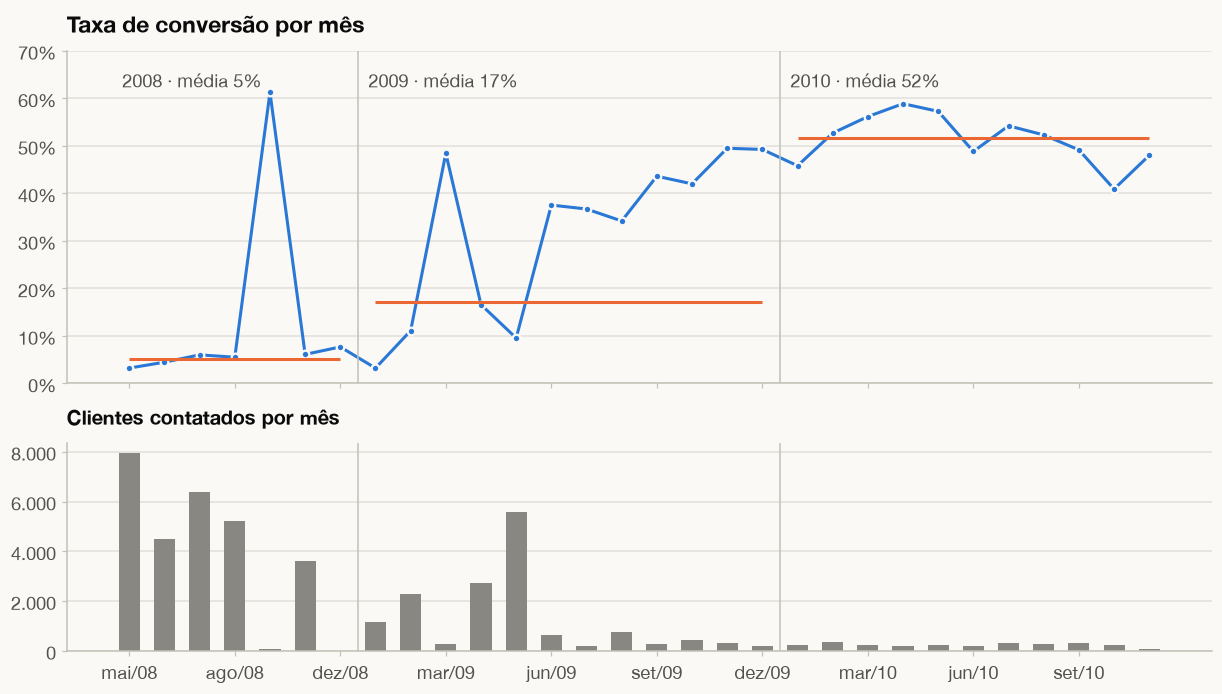

In [11]:
fig, (ax_rate, ax_vol) = plots.new_figure(11, 6.2, nrows=2, sharex=True, height_ratios=[1.6, 1])
x = np.arange(len(by_period))
labels = [f"{MONTHS_PT[int(p[5:]) - 1]}/{p[2:4]}" for p in by_period.index]

ax_rate.plot(x, by_period["conversion"], color=BLUE, marker="o", markersize=5,
             markeredgecolor=plots.SURFACE, markeredgewidth=1.5)
ax_rate.set_ylim(0, 0.7)
plots.percent_axis(ax_rate)
ax_rate.set_title("Taxa de conversão por mês")
for year, row in by_year.iterrows():
    months = [i for i, p in enumerate(by_period.index) if p.startswith(str(year))]
    if year > 2008:
        for ax in (ax_rate, ax_vol):
            ax.axvline(months[0] - 0.5, color=BASELINE, linewidth=1)
    ax_rate.hlines(row["conversion"], months[0], months[-1], color=ORANGE, linewidth=2)
    ax_rate.text(months[0] - 0.2, 0.66, f"{year} · média {plots.fmt_pct(row['conversion'])}",
                 color=INK_2, fontsize=12, va="top")

ax_vol.bar(x, by_period["calls"], color=GRAY, width=0.6)
ax_vol.set_title("Clientes contatados por mês", fontsize=13)
plots.thousands_axis(ax_vol)
ax_vol.set_xticks(x[::3], labels[::3])
plots.save(fig, "eda_conversao_tempo")

**O que mudou ao longo do tempo**
- A conversão sai de **5,1% (2008)** para **17,1% (2009)** e **51,6% (2010)**, enquanto o volume despenca: em
  2008 o banco ligou em massa; em 2010 fez poucas ligações, muito mais seletivas.
- O perfil de quem é chamado muda junto: a fatia de clientes **já contatados antes** sobe de ~3% (2008) para
  ~66% (2010), e a média de tentativas cai de 3,2 para 1,9.
- `contact = unknown` é basicamente **mai–jun/2008** (100% das linhas), depois quase desaparece. Ainda assim
  há 251 casos em 2010, que convertem bem menos que o celular.

**Consequência:** a época explica boa parte da conversão. Qualquer comparação que misture 2008 com 2010 pode
atribuir ao perfil do cliente um efeito que na verdade é do período. Isso aparece nos "meses bons":

In [12]:
month_mix = pd.crosstab(df["month"], df["year"], normalize="index").loc[["mar", "sep", "oct", "dec", "may", "jun", "jul", "aug"]]
month_mix.assign(conversion=df.groupby("month")["y"].mean())

year,2008,2009,2010,conversion
month,,,,
mar,0.000,0.541,0.459,0.520
sep,0.000,0.487,0.513,0.465
oct,0.108,0.593,0.298,0.438
dec,0.061,0.939,0.000,0.467
may,0.578,0.405,0.017,0.067
jun,0.840,0.120,0.040,0.102
jul,0.925,0.030,0.045,0.091
aug,0.835,0.124,0.042,0.110


Março, setembro, outubro e dezembro "convertem 44–52%", mas 89–100% dessas ligações são de 2009–2010.
Maio–agosto são majoritariamente de 2008. Com só 2,5 anos em forte mudança **não dá para separar sazonalidade
de tendência**. Por isso `day` e `month` não entram no modelo como features (ver seção 11).

In [13]:
contact_by_year = pd.crosstab(df["contact"], df["year"])
print(contact_by_year)
print("\nconversão em 2010 por canal:\n", df[df["year"] == 2010].groupby("contact")["y"].agg(["size", "mean"]))

year        2008   2009  2010
contact                      
cellular   13625  13559  2101
telephone   1339   1299   268
unknown    12765      4   251

conversão em 2010 por canal:
            size  mean
contact              
cellular   2101 0.571
telephone   268 0.455
unknown     251 0.120


## 6. Variáveis numéricas e outliers

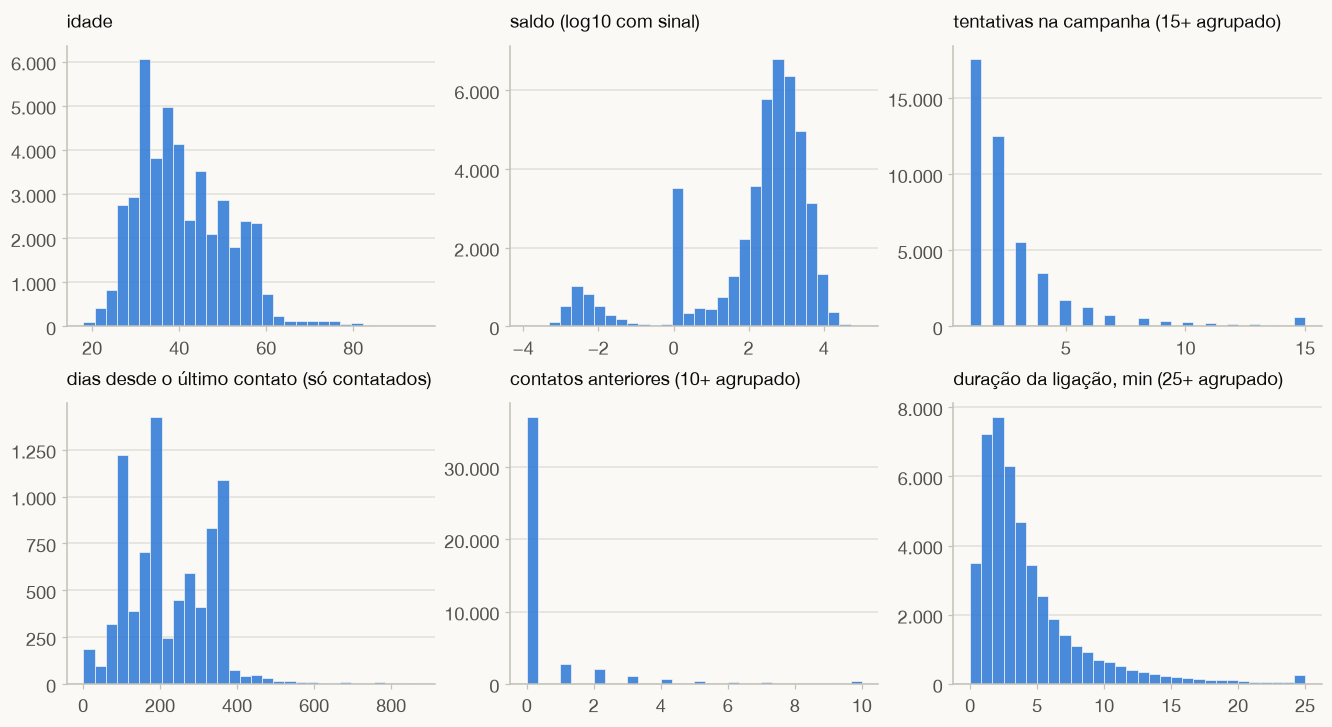

In [14]:
fig, axes = plots.new_figure(12, 6.5, nrows=2, ncols=3)
panels = [
    ("age", df["age"], "idade"),
    ("balance", np.sign(df["balance"]) * np.log10(1 + df["balance"].abs()), "saldo (log10 com sinal)"),
    ("campaign", df["campaign"].clip(upper=15), "tentativas na campanha (15+ agrupado)"),
    ("pdays", df.loc[df["pdays"] >= 0, "pdays"], "dias desde o último contato (só contatados)"),
    ("previous", df["previous"].clip(upper=10), "contatos anteriores (10+ agrupado)"),
    ("duration", df["duration"].clip(upper=1500) / 60, "duração da ligação, min (25+ agrupado)"),
]
for ax, (_, values, title) in zip(axes.flat, panels):
    ax.hist(values, bins=30, color=BLUE, alpha=0.85, edgecolor=plots.SURFACE, linewidth=0.5)
    ax.set_title(title, fontsize=12, fontweight="normal")
    plots.thousands_axis(ax)
plots.save(fig, "eda_distribuicoes")

In [15]:
numeric = ["age", "balance", "campaign", "pdays", "previous", "duration"]
q1, q3 = df[numeric].quantile(0.25), df[numeric].quantile(0.75)
iqr_out = (df[numeric] < q1 - 1.5 * (q3 - q1)) | (df[numeric] > q3 + 1.5 * (q3 - q1))
pd.DataFrame({"skew": df[numeric].skew(), "% fora da regra 1,5·IQR": iqr_out.mean()})

,skew,"% fora da regra 1,5·IQR"
age,0.685,0.011
balance,8.360,0.105
campaign,4.899,0.068
pdays,2.616,0.183
previous,41.846,0.183
duration,3.144,0.072


**Outliers: nenhuma remoção.** A regra de 1,5·IQR marcaria 7–18% das linhas de `balance`, `campaign`,
`pdays` e `previous` como "outliers", mas são valores reais: clientes com saldo alto, muitas tentativas ou
histórico longo. Removê-los traz três problemas:
1. enviesa o treino;
2. em produção não dá para "remover" um cliente, o modelo precisa pontuar todos;
3. as caudas carregam sinal.

O tratamento fica no modelo: árvores são robustas a caudas; na regressão logística usamos log/log com sinal e
padronização. O único ponto suspeito é `previous = 275`, um único cliente, que também fica.

## 7. Variáveis categóricas

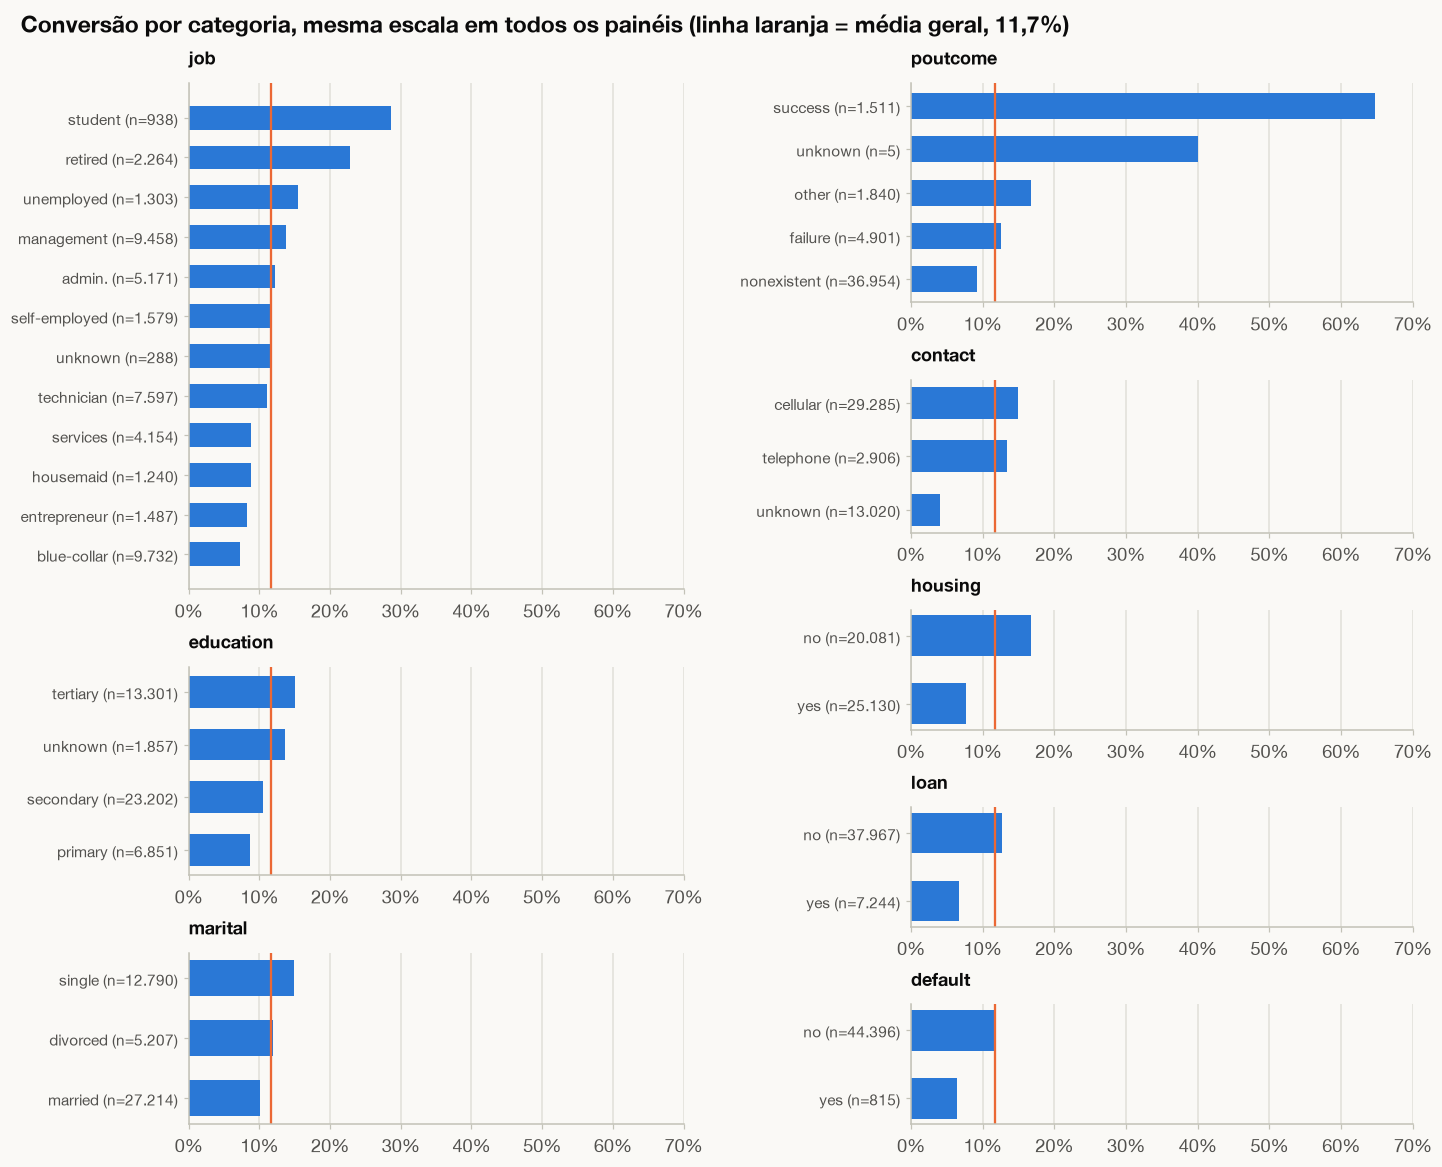

In [16]:
columns_layout = [["job", "education", "marital"], ["poutcome", "contact", "housing", "loan", "default"]]
fig = plt.figure(figsize=(13, 10.5), layout="constrained")
for sub, cols in zip(fig.subfigures(1, 2, wspace=0.04), columns_layout):
    axes = sub.subplots(len(cols), 1, height_ratios=[df[c].nunique() + 1.6 for c in cols])
    for ax, col in zip(axes, cols):
        rates = df.groupby(col)["y"].agg(["mean", "size"]).sort_values("mean")
        labels = [f"{cat} (n={plots.fmt_num(n)})" for cat, n in zip(rates.index, rates["size"])]
        ax.barh(labels, rates["mean"], color=BLUE, height=0.6)
        ax.axvline(base_rate, color=ORANGE, linewidth=1.5)
        ax.set_title(col, fontsize=12)
        ax.set_xlim(0, 0.7)
        ax.grid(axis="y", visible=False)
        ax.grid(axis="x", visible=True)
        plots.percent_axis(ax, axis="x")
        ax.tick_params(axis="y", labelsize=10)
fig.suptitle("Conversão por categoria, mesma escala em todos os painéis (linha laranja = média geral, 11,7%)",
             x=0.01, ha="left", fontsize=15, fontweight="bold")
plots.save(fig, "eda_categoricas")

À primeira vista:
- Estudantes e aposentados convertem 2–3× a média.
- Quem tem sucesso numa campanha anterior converte 65%.
- Crédito imobiliário e empréstimo pessoal reduzem a conversão.
- `contact = unknown` converte muito pouco.

**Mas estes números misturam épocas.** A próxima seção testa quais efeitos sobrevivem quando comparamos
clientes ligados no mesmo mês.

## 8. Relação com o alvo: perfil ou época?

Para cada segmento calculamos dois *lifts*:
- **na base toda** = conversão do segmento ÷ conversão média (o que a seção 7 mostra);
- **no mesmo mês** = adesões observadas ÷ adesões esperadas se cada cliente convertesse à taxa do mês em que
  foi ligado (`eda.lift_by`). Se o segmento só "parece bom" porque foi ligado em meses bons, esse lift vai a ~1.

In [17]:
seg = df.assign(
    age_band=pd.cut(df["age"], [0, 25, 59, 200], labels=["18–25", "26–59", "60+"]),
    balance_band=pd.cut(df["balance"], [-np.inf, -1, 4999, np.inf], labels=["negativo", "0–5 mil", "≥ 5 mil"]),
)
segments = {
    "Sucesso na campanha anterior": ("poutcome", "success"),
    "60+ anos": ("age_band", "60+"),
    "Estudante": ("job", "student"),
    "18–25 anos": ("age_band", "18–25"),
    "Aposentado": ("job", "retired"),
    "Sem crédito imobiliário": ("housing", "no"),
    "Celular": ("contact", "cellular"),
    "Telefone fixo": ("contact", "telephone"),
    "Fracasso na campanha anterior": ("poutcome", "failure"),
    "Com crédito imobiliário": ("housing", "yes"),
    "Com empréstimo pessoal": ("loan", "yes"),
    "Saldo negativo": ("balance_band", "negativo"),
    "Canal não registrado": ("contact", "unknown"),
}
lift_tables = {col: lift_by(seg, col) for col in {c for c, _ in segments.values()}}
lifts = pd.DataFrame(
    {name: lift_tables[col].loc[value, ["n", "rate", "pooled_lift", "adjusted_lift"]] for name, (col, value) in segments.items()}
).T.astype(float)
lifts

,n,rate,pooled_lift,adjusted_lift
Sucesso na campanha anterior,1511.000,0.647,5.533,1.605
60+ anos,1784.000,0.336,2.875,1.068
Estudante,938.000,0.287,2.451,1.077
18–25 anos,1336.000,0.240,2.047,1.217
Aposentado,2264.000,0.228,1.948,1.055
Sem crédito imobiliário,20081.000,0.167,1.428,1.092
Celular,29285.000,0.149,1.275,1.047
Telefone fixo,2906.000,0.134,1.147,0.788
Fracasso na campanha anterior,4901.000,0.126,1.078,0.659
Com crédito imobiliário,25130.000,0.077,0.658,0.873


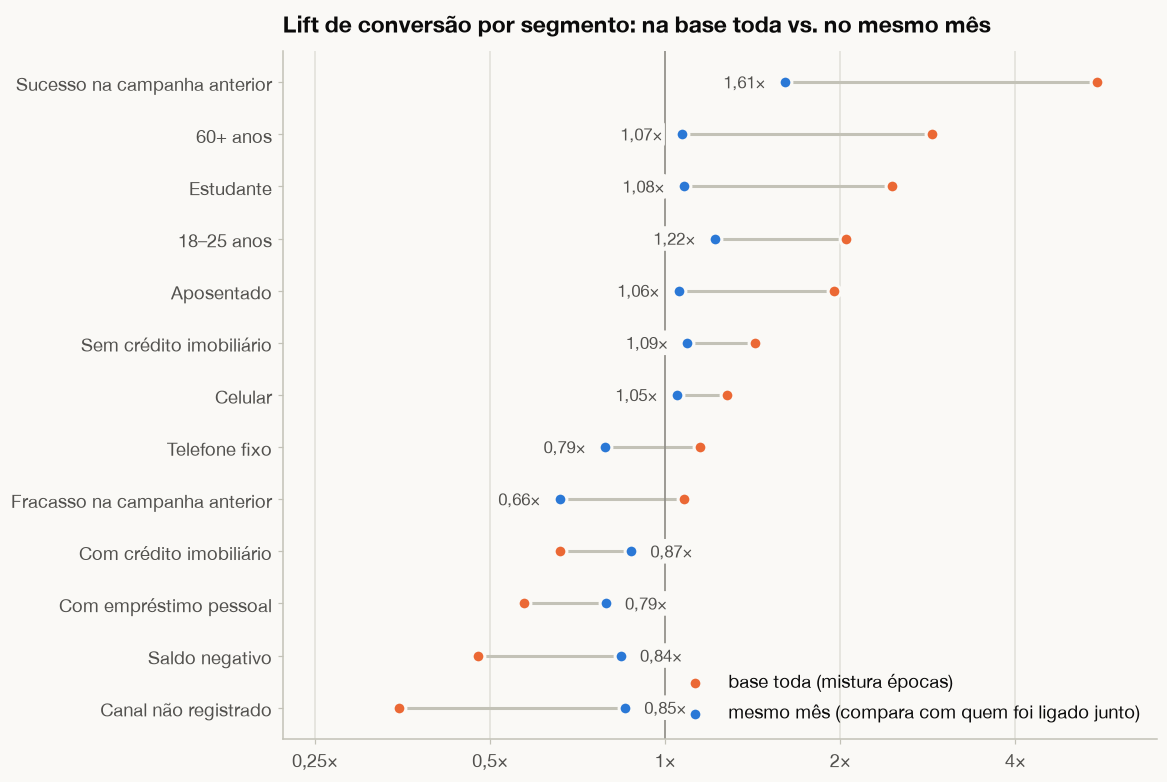

In [18]:
fig, ax = plots.new_figure(10.5, 7)
order = lifts.sort_values("pooled_lift").index
y_pos = np.arange(len(order))
ax.hlines(y_pos, lifts.loc[order, "adjusted_lift"], lifts.loc[order, "pooled_lift"], color=BASELINE, linewidth=2)
ax.scatter(lifts.loc[order, "pooled_lift"], y_pos, color=ORANGE, s=70, zorder=3,
           edgecolor=plots.SURFACE, linewidth=2, label="base toda (mistura épocas)")
ax.scatter(lifts.loc[order, "adjusted_lift"], y_pos, color=BLUE, s=70, zorder=3,
           edgecolor=plots.SURFACE, linewidth=2, label="mesmo mês (compara com quem foi ligado junto)")
for yp, name in zip(y_pos, order):
    adj, pooled = lifts.loc[name, "adjusted_lift"], lifts.loc[name, "pooled_lift"]
    outside_left = adj <= pooled
    ax.text(adj / 1.08 if outside_left else adj * 1.08, yp, plots.fmt_times(adj),
            ha="right" if outside_left else "left", va="center", fontsize=11, color=INK_2,
            bbox={"boxstyle": "round,pad=0.15", "facecolor": plots.SURFACE, "edgecolor": "none"})
ax.axvline(1, color=MUTED, linewidth=1)
ax.set_xscale("log")
ax.set_xticks([0.25, 0.5, 1, 2, 4], ["0,25×", "0,5×", "1×", "2×", "4×"])
ax.minorticks_off()
ax.set_xlim(0.22, 7)
ax.set_yticks(y_pos, order)
ax.grid(axis="y", visible=False)
ax.grid(axis="x", visible=True)
ax.set_title("Lift de conversão por segmento: na base toda vs. no mesmo mês")
ax.legend(loc="lower right")
plots.save(fig, "eda_perfil_vs_epoca")

**Paradoxo de Simpson.** Vários efeitos "fortes" de perfil eram, na verdade, efeitos de época:
- **60+ anos** (2,9× → ~1,07×), **estudantes** (2,5× → ~1,08×) e **aposentados** (2,0× → ~1,06×) praticamente
  somem. Só 23% dos clientes 60+ foram ligados em 2008, o período de 5% de conversão, contra 61% da base.
- Alguns efeitos **invertem**. `poutcome = failure` e telefone fixo parecem acima da média na base toda, mas
  ficam abaixo dela quando comparados no mesmo mês.
- **Sobrevivem:**
  - sucesso anterior (1,6×);
  - crédito imobiliário (0,87×) e empréstimo pessoal (0,79×);
  - saldo negativo (0,84×);
  - celular vs. fixo;
  - jovens 18–25 (1,2×).

**Ressalva:** a taxa do mês também reflete *quem o banco escolheu ligar* naquele mês. A comparação no mesmo mês
é a mais conservadora, mas não é um limite exato. A regressão logística com efeito fixo de mês (notebook 03)
confirma as direções.

**Implicação para o modelo:** ele precisa comparar clientes **dentro do mesmo período**. Senão vai priorizar
"60+" em toda campanha futura por causa de um artefato de 2008–2010.

## 9. Quantas vezes ligar: tentativas

`campaign` é o número de ligações feitas **até o desfecho**, e o banco para de ligar quando o cliente diz
"sim". Então agrupar por `campaign` tem **viés de sobrevivência**: quem aparece com `campaign = 1` inclui todo
mundo que aderiu na primeira ligação. O certo é a **taxa por tentativa**, isto é, adesões na k-ésima ligação
÷ clientes que receberam uma k-ésima ligação.

In [19]:
hazard = attempt_hazard(df)
naive = df.groupby(df["campaign"].clip(upper=10))["y"].mean().rename("taxa_ingenua_por_campaign")
hazard.head(10).set_index("attempt").join(naive)

,reached,conversions,hazard,cum_conversion_share,cum_call_share,taxa_ingenua_por_campaign
attempt,,,,,,
1,45211,2561,0.057,0.484,0.362,0.146
2,27667,1401,0.051,0.749,0.583,0.112
3,15162,618,0.041,0.866,0.705,0.112
4,9641,317,0.033,0.926,0.782,0.090
5,6119,139,0.023,0.952,0.831,0.079
6,4355,92,0.021,0.970,0.866,0.071
7,3064,47,0.015,0.978,0.890,0.064
8,2329,32,0.014,0.984,0.909,0.059
9,1789,21,0.012,0.988,0.923,0.064


**Mas a queda na base toda mistura épocas.** A maioria das ligações além da 3ª foi feita em 2008, quando *toda*
ligação convertia pouco. Para separar o efeito da tentativa do efeito da época, comparamos cada tentativa com
uma ligação média **do mesmo mês** (`eda.attempt_lift`): 1,0 significa que a k-ésima ligação converte como uma
ligação típica daquele mês.

In [20]:
lift_attempt = attempt_lift(df).head(8).set_index("attempt")
per_year = pd.DataFrame({
    year: [((g["campaign"] == k) & (g["y"] == 1)).sum() / (g["campaign"] >= k).sum() for k in range(1, 7)]
    for year, g in df.groupby("year")
}, index=range(1, 7))
per_year.index.name = "tentativa"
extra = (df["campaign"] - 3).clip(lower=0)
print("fração das ligações além da 3ª feitas em 2008:", plots.fmt_pct(extra[df["year"] == 2008].sum() / extra.sum()))
display(lift_attempt[["observed", "expected", "ratio"]])
per_year

fração das ligações além da 3ª feitas em 2008: 84%


,observed,expected,ratio
attempt,,,
1,2561,2487.828,1.029
2,1401,1242.421,1.128
3,618,595.979,1.037
4,317,325.738,0.973
5,139,191.704,0.725
6,92,119.708,0.769
7,47,75.997,0.618
8,32,51.509,0.621


,2008,2009,2010
tentativa,,,
1,0.017,0.090,0.283
2,0.020,0.088,0.283
3,0.017,0.076,0.280
4,0.020,0.053,0.233
5,0.011,0.049,0.187
6,0.016,0.026,0.200


In [21]:
caps = pd.DataFrame({cap: cap_attempts_impact(df, cap) for cap in range(1, 7)}).T
caps.index.name = "máximo de tentativas"
caps

,calls_saved_share,conversions_lost_share,conversion_rate_of_saved_calls,relative_rate_of_saved_calls
máximo de tentativas,,,,
1,0.638,0.516,0.034,0.974
2,0.417,0.251,0.025,0.851
3,0.295,0.134,0.019,0.736
4,0.218,0.074,0.014,0.615
5,0.169,0.048,0.012,0.568
6,0.134,0.030,0.010,0.494


{'calls_saved_share': np.float64(0.21827683344537277),
 'conversions_lost_share': np.float64(0.07411608999810929),
 'conversion_rate_of_saved_calls': np.float64(0.014372135655362054),
 'relative_rate_of_saved_calls': np.float64(0.6153519803465856)}

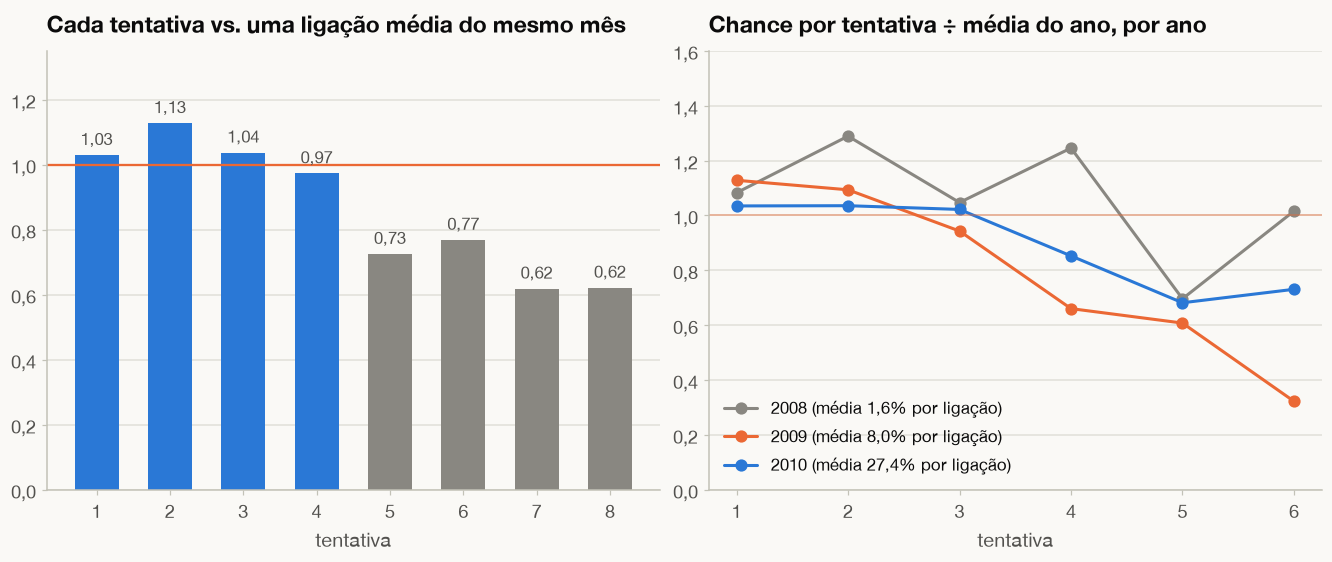

In [22]:
fig, (ax_l, ax_y) = plots.new_figure(12, 5, ncols=2)
colors = [BLUE if k <= 4 else GRAY for k in lift_attempt.index]
ax_l.bar(lift_attempt.index, lift_attempt["ratio"], color=colors, width=0.6)
ax_l.axhline(1, color=ORANGE, linewidth=1.5)
for k, v in lift_attempt["ratio"].items():
    ax_l.text(k, v + 0.02, plots.fmt_num(v, 2), ha="center", va="bottom", fontsize=11, color=INK_2)
ax_l.set_xticks(lift_attempt.index)
ax_l.set_xlabel("tentativa")
ax_l.set_ylim(0, 1.35)
plots.decimal_axis(ax_l, "y", 1)
ax_l.set_title("Cada tentativa vs. uma ligação média do mesmo mês")

year_colors = {2008: GRAY, 2009: ORANGE, 2010: BLUE}
avg_per_call = df.groupby("year")["y"].sum() / df.groupby("year")["campaign"].sum()
for year, color in year_colors.items():
    rel = per_year[year] / avg_per_call[year]
    ax_y.plot(rel.index, rel, color=color, marker="o", label=f"{year} (média {plots.fmt_pct(avg_per_call[year], 1)} por ligação)")
ax_y.axhline(1, color=ORANGE, linewidth=1, alpha=0.5)
ax_y.set_xticks(per_year.index)
ax_y.set_xlabel("tentativa")
ax_y.set_ylim(0, 1.6)
plots.decimal_axis(ax_y, "y", 1)
ax_y.set_title("Chance por tentativa ÷ média do ano, por ano")
ax_y.legend(loc="lower left", fontsize=11)
plots.save(fig, "eda_tentativas")

cap3, cap4 = cap_attempts_impact(df, 3), cap_attempts_impact(df, 4)
eda_facts.update(
    hazard_first_five=hazard["hazard"].head(5).round(4).tolist(),
    cum_conversion_share_at_3=float(hazard.loc[2, "cum_conversion_share"]),
    cum_call_share_at_3=float(hazard.loc[2, "cum_call_share"]),
    attempt_ratio_same_month=lift_attempt["ratio"].round(3).tolist(),
    extra_calls_share_2008=float(extra[df["year"] == 2008].sum() / extra.sum()),
    cap3=cap3,
    cap4=cap4,
)
cap4

**Leitura**
- Na base toda, a chance por tentativa cai de **5,7%** (1ª) para **2,3%** (5ª). A taxa "ingênua" por
  `campaign` (14,6% na 1ª) superestima porque mistura desfecho com esforço.
- Mas **84% das ligações além da 3ª são de 2008**. Comparando com o mesmo mês, as tentativas 1–4 rendem
  perto da média (0,97–1,13×) e **da 5ª em diante o retorno cai** (~0,6–0,8×).
- Ano a ano: as **três primeiras** rendem como a média do ano em todos os anos. A **4ª** já cai em 2009 (0,66×)
  e 2010 (0,85×), mas não em 2008 (poucos casos). **Da 5ª em diante** cai em todos os anos.
- **Limite de 4 tentativas:** economiza **21,8% das ligações** e perde **7,4% das adesões**; as ligações cortadas
  convertem **0,62×** uma ligação média do mesmo mês. O limite de 3, que parecia melhor na base toda
  (−29,5% de ligações), corta ligações que ainda rendiam 0,74× a média do mês.
- **Limite padrão de 4**, com ajuste pelo "clima", porque o limite ideal depende dele:
  - em 2009 (8% por ligação), a 4ª tentativa (5,3%) já não pagaria um limiar de custo de 10%;
  - em 2010 (27%), até a 5ª (18,7%) paga folgado.

  A decisão fina é a mesma regra de custo do modelo, `p ≥ C/V`, aplicada por tentativa.

É uma **regra de negócio** (quantas vezes insistir), separada do modelo (quem ligar). Por isso `campaign` não
entra como feature do score: ela conta tentativas *até o desfecho*, ou seja, depende do próprio alvo.

## 10. `duration` e vazamento de informação

In [23]:
dur = df.assign(duration_band=pd.cut(df["duration"], [-1, 60, 120, 300, 600, 5000],
                                     labels=["≤1 min", "1–2 min", "2–5 min", "5–10 min", ">10 min"]))
dur.groupby("duration_band", observed=True)["y"].agg(["size", "mean"])

,size,mean
duration_band,,
≤1 min,4766,0.002
1–2 min,9278,0.022
2–5 min,18893,0.086
5–10 min,8484,0.192
>10 min,3790,0.484


`duration` é a variável mais "preditiva" do dataset: ligações de até 1 minuto quase nunca convertem, e as de
mais de 10 minutos convertem quase metade das vezes (48%). Mas **ela só existe depois que a ligação termina**, quando o
resultado já é conhecido. A própria documentação da UCI recomenda descartá-la para um modelo realista. Ela fica
**fora do modelo** e só aparece num benchmark de apêndice, para mostrar quanto infla as métricas.

Como insight operacional, conversa longa se associa a adesão. Qualidade do roteiro e do atendimento importa,
mas isso é correlação sobre o que acontece *durante* a ligação, não um critério para escolher quem ligar.

## 11. Quando cada variável é conhecida → conjunto de features

O princípio foi definido antes de olhar os resultados do modelo: **só entra o que é conhecido antes da ligação
e não é um indicador de época**.

| Variável | Quando é conhecida | Decisão |
|---|---|---|
| `age`, `job`, `marital`, `education`, `default`, `balance`, `housing`, `loan` | antes da campanha | **usar** |
| `pdays`, `previous`, `poutcome` (+ flag `contacted_before`) | antes da campanha (histórico) | **usar** |
| `contact` | antes da ligação (canal) | **usar** |
| `day`, `month` | data do *último* contato; confundidas com a época | fora; a época entra como **controle** no modelo |
| `campaign` | total de tentativas até o desfecho | fora; vira a **regra de tentativas** |
| `duration` | só depois da ligação | fora (**vazamento**); só benchmark |

In [24]:
print("features do modelo (F0):", FEATURES)
print("excluídas:", EXCLUDED)

features do modelo (F0): ['job', 'marital', 'education', 'contact', 'poutcome', 'default', 'housing', 'loan', 'age', 'balance', 'pdays', 'previous', 'contacted_before']
excluídas: ['duration', 'campaign', 'day', 'month']


## 12. Resumo dos achados

1. **Dados limpos, mas com ausência disfarçada.** `unknown` é informativo e estrutural, então é mantido como
   categoria; `poutcome` é recodificado.
2. **Desbalanceamento.** 11,7% por cliente e 4,2% por ligação; acurácia é enganosa.
3. **Tempo.** A conversão vai de 5% para 52% entre 2008 e 2010, e o mix de clientes muda junto.
4. **Perfil ou época?** Idade e profissão parecem fortes, mas são quase todo época. Sucesso anterior,
   endividamento, saldo e canal sobrevivem.
5. **Tentativas.** Comparando no mesmo mês, as 4 primeiras ligações rendem como a média e a queda começa na 5ª.
   Limitar a 4 corta 21,8% das ligações e perde 7,4% das adesões.
6. **Vazamento.** `duration` fica fora; `campaign`, `day` e `month` também, por dependerem do desfecho ou da época.

Próximo passo, no notebook 02: modelo que ordena clientes **dentro do mesmo período** e avaliação com métricas
de ordenação e de negócio.

In [25]:
eda_facts.update(
    unknown_pct={k: float(v) for k, v in unknowns["pct_unknown"].items()},
    conversion_by_year={int(k): float(v) for k, v in by_year["conversion"].items()},
    contacted_before_by_year={int(k): float(v) for k, v in by_year["contacted_before"].items()},
    avg_attempts_by_year={int(k): float(v) for k, v in by_year["avg_attempts"].items()},
    n_periods=int(df["period"].nunique()),
    segment_lifts={name: {"pooled": float(r["pooled_lift"]), "adjusted": float(r["adjusted_lift"]),
                          "rate": float(r["rate"]), "n": int(r["n"])} for name, r in lifts.iterrows()},
    bank_cleaned_rows_dropped=int(len(dropped)),
)
save_metrics("eda", eda_facts)
print("seção 'eda' salva em reports/metrics.json")

seção 'eda' salva em reports/metrics.json
